In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 데이터셋(훈련셋, 테스트셋)
from tensorflow.keras.utils import to_categorical  # onehot encoding
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.model_selection import train_test_split

In [4]:
width = 28; height=28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

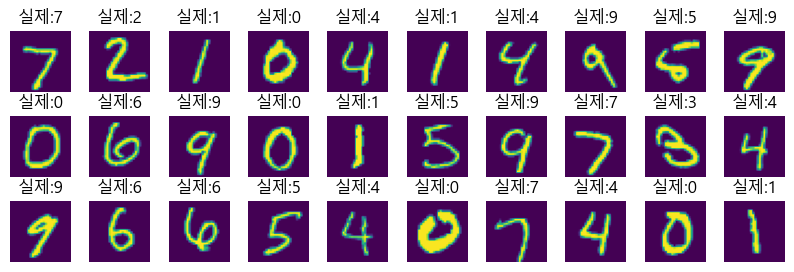

In [12]:
plt_row=3
plt_col=10
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
plt.rc('font', family='Malgun Gothic') # window에서 한글 시각화
# plt.rc('font', family='NanumBarunGothic')  # 코랩에서 한글 시각화

fig, axes = plt.subplots(plt_row, plt_col)

# axes[0,0].imshow(X_test[0].reshape(width, height))
# axes[0,0].axis('off')
# title = f'실제:{y_test[0]}'
# axes[0,0].set_title(title)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
# plt.tight_layout()
for i in range(plt_row*plt_col):    
    row_idx = i//10
    col_idx = i%10 
    subax= axes[row_idx,col_idx]
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = f'실제:{y_test[i]}'
    subax.set_title(title)


# 1. DNN

In [17]:
%%time
# 1. 데이터 생성 및 전처리
width=28; height=28
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# X_train.shape, y_train.shape, X_test.shape, y_test.shape
X_train = X_train.reshape(60000, -1).astype('float32')/255.0
X_test = X_test.reshape(10000, -1).astype('float32')/255.0

X_train.shape, y_train.shape, X_test.shape, y_test.shape

# 2. 모델 구성
model= Sequential([
    Input(shape=(784,)),
    Dense(units=1000, activation='relu'),
    Dropout(0.3),
    Dense(units=500, activation='relu'),
    Dropout(0.2),
    Dense(units=300, activation='relu'),
    Dropout(0.2),
    Dense(units=10, activation='softmax')
])
model.summary()

# 3. 학습과정 설정
model.compile(loss = 'sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

# 4. 학습하기
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
earlyStopping = EarlyStopping(patience=4)
folder = './model_mnist/'
if not folder:
    os.mkdir(folder)
file= folder+ "mnist_{epoch}_val{val_accuracy}.h5"
auto_save = ModelCheckpoint(filepath=file, verbose=1)

hist = model.fit(X_train, y_train,
                epochs= 30,
                validation_split=0.2,
                verbose=1,
                batch_size=1000,
                callbacks=[earlyStopping, auto_save]
                )

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 1000)              785000    
                                                                 
 dropout (Dropout)           (None, 1000)              0         
                                                                 
 dense_5 (Dense)             (None, 500)               500500    
                                                                 
 dropout_1 (Dropout)         (None, 500)               0         
                                                                 
 dense_6 (Dense)             (None, 300)               150300    
                                                                 
 dropout_2 (Dropout)         (None, 300)               0         
                                                                 
 dense_7 (Dense)             (None, 10)               

In [40]:
y_test.shape, y_test.shape
Y_test = to_categorical(y_test)
print('실제값 :', np.argmax(Y_test, axis=1))

실제값 : [7 2 1 ... 4 5 6]


In [41]:
from sklearn.metrics import confusion_matrix
print('실제값 :', y_test)
print('실제값 :', np.argmax(Y_test, axis=1))
yhat= model.predict(X_test).argmax(axis=1)
cmatrix = confusion_matrix(y_test, yhat)
cmatrix

실제값 : [7 2 1 ... 4 5 6]
실제값 : [7 2 1 ... 4 5 6]
313/313 [==============================] - 1s 4ms/step


array([[ 970,    1,    0,    2,    0,    1,    3,    1,    1,    1],
       [   0, 1127,    1,    1,    0,    1,    3,    0,    2,    0],
       [   2,    0, 1013,    4,    1,    0,    1,    7,    3,    1],
       [   0,    0,    1, 1000,    0,    2,    0,    4,    2,    1],
       [   1,    0,    3,    0,  957,    0,    5,    2,    1,   13],
       [   1,    0,    0,   13,    1,  869,    2,    1,    3,    2],
       [   1,    2,    0,    1,    3,    5,  944,    0,    2,    0],
       [   0,    1,    6,    2,    0,    0,    0, 1014,    1,    4],
       [   0,    0,    2,    9,    4,    5,    0,    2,  949,    3],
       [   1,    2,    0,    6,    3,    1,    0,    7,    0,  989]],
      dtype=int64)

In [35]:
# 실제값과 예측값이 다른 갯수(방법2)

cnt = 0
for y, h in zip(y_test, yhat):
    if y != h:
        cnt +=1
print('예측이 틀린 갯수 : ', cnt)

예측이 틀린 갯수 :  168


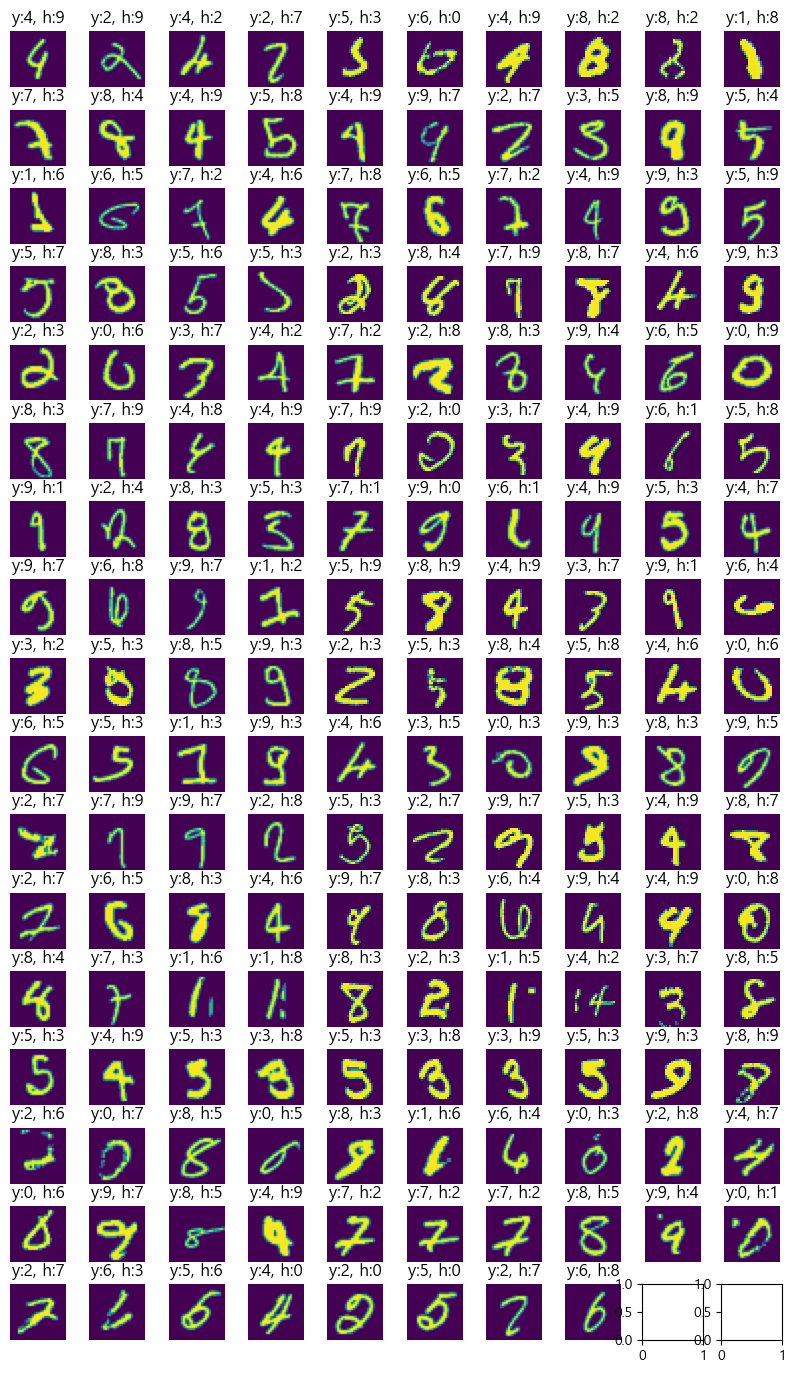

In [46]:
# DNN을 사용하여 예측이 틀린 데이터 출력(yhat != y_test)
plt_row=17
plt_col=10
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
plt.rc('font', family='Malgun Gothic') # window에서 한글 시각화
# plt.rc('font', family='NanumBarunGothic')  # 코랩에서 한글 시각화

fig, axes = plt.subplots(plt_row, plt_col)
plt.subplots_adjust(hspace=0.4, wspace=0.3)
i = 0
cnt = 0 # 이미지 출력횟수
while i < len(y_test) and cnt < plt_row*plt_col:
    if yhat[i] == y_test[i]:
        i += 1
        continue
    
    subax= axes[cnt//10,cnt%10]
    subax.imshow(X_test[i].reshape(width, height))
    subax.axis('off')
    title = f'y:{y_test[i]}, h:{yhat[i]}'
    subax.set_title(title)
    i += 1  # 인덱스 증가
    cnt += 1  # 이미지 출력 번호 증가

# CNN (컴볼루션 레이어 포함)
- 교재 31p

In [49]:
# 1. 데이터 세팅
# 데이터 생성
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋 (6만개) -> 훈련셋(5만개) + 검증셋(1만개)로 분리
X_val = X_train[-10000:]
y_val = y_train[-10000:]
X_train = X_train[:-10000]
y_train = y_train[:-10000]

# 입력(독립)변수(n, 28,28) -> (n, 784)  # 1차원, 실수형변환, 스케일조정(255.0으로 나누기)
X_train = X_train.reshape(50000,784).astype('float32')/255.0
X_val = X_val.reshape(10000,-1).astype('float32')/255
X_test = X_test.reshape(10000,-1).astype('float32')/255

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((50000, 784), (50000,), (10000, 784), (10000,), (10000, 784), (10000,))

In [ ]:
# 2. 모델 생성